# Ex No 10 - Demonstrate Augmented reality using feature matching 


Object detected and AR applied!


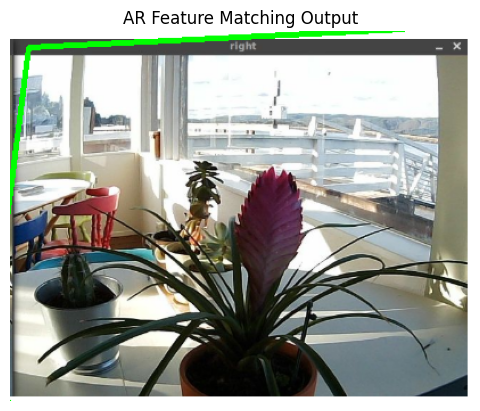

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Load images
img1 = cv2.imread(r"D:\SEM 6\IPCV\left.png")
img2 = cv2.imread(r"D:\SEM 6\IPCV\right.png")

if img1 is None or img2 is None:
    print("Error loading images")
    exit()

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. ORB feature detection
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# 3. Feature matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING)
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# 4. Homography
if len(good_matches) > 10:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 5. Draw boundary
    h, w = img1.shape[:2]
    pts = np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)
    dst = cv2.perspectiveTransform(pts, H)

    img2 = cv2.polylines(img2, [np.int32(dst)], True, (0,255,0), 3)

    print("Object detected and AR applied!")
else:
    print("Not enough matches found!")

# 6. Display using matplotlib (FIX)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img2_rgb)
plt.title("AR Feature Matching Output")
plt.axis('off')
plt.show()